In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
%pushd "/content/drive/MyDrive/MSSP607/"

/content/drive/MyDrive/MSSP607


['/content']

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

# seaborn is a package for the visualization of statistical data
import seaborn as sns
sns.set(style='ticks')

In [30]:
score = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Week12/Student Performance Data.csv')

In [31]:
score.head(10)

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high
5,female,group B,associate's degree,standard,71,83,78,232,none,high
6,female,group B,some college,standard,88,95,92,275,completed,high
7,male,group B,some college,free/reduced,40,43,39,122,none,low
8,male,group D,high school,free/reduced,64,64,67,195,completed,medium
9,female,group B,high school,free/reduced,38,60,50,148,none,low


In [32]:
score = score.dropna()

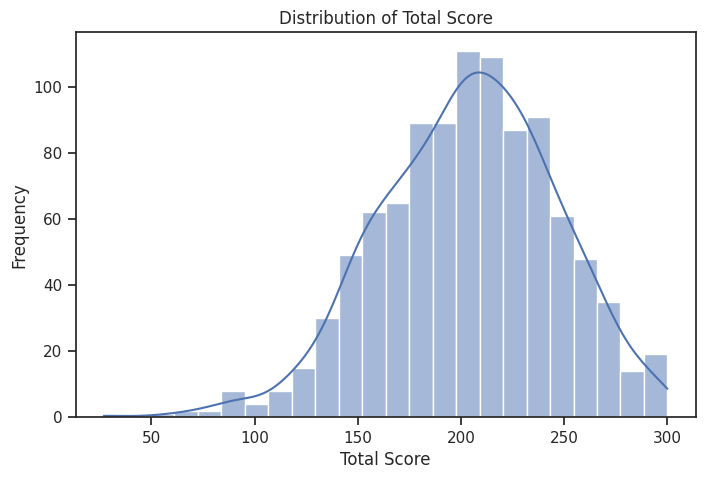

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(score['total score'], kde=True)
plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Frequency")
plt.show()

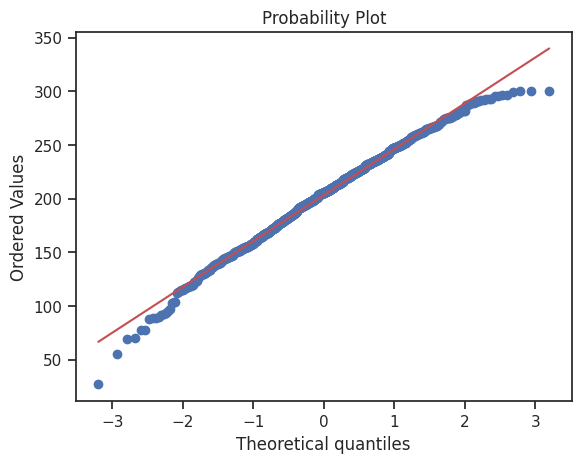

In [53]:
_ = stats.probplot(score['total score'], plot=plt)

**complete a t-test on a group of students from the Student Performance Data Set located**

In [34]:
group_completed = score[score['test preparation course'] == 'completed']['total score']
group_none = score[score['test preparation course'] == 'none']['total score']

In [35]:
from scipy.stats import levene

statistic, p_value = levene(group_completed, group_none)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 2.885
Levene's Test p-value: 0.090
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [36]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(group_completed, group_none, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between students who completed the test preparation course and those who did not.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between students who completed the test preparation course and those who did not.")


Independent samples t-statistic: 8.391
Independent samples p-value: 0.000
Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between students who completed the test preparation course and those who did not.


** Is there a statistical difference between males who took the preparation exam and others?**

In [37]:
male_students = score[score['gender'] == 'male']
male_completed_prep = male_students[male_students['test preparation course'] == 'completed']['total score']
male_none_prep = male_students[male_students['test preparation course'] == 'none']['total score']


In [38]:
from scipy.stats import levene

statistic, p_value = levene(male_completed_prep, male_none_prep)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 0.002
Levene's Test p-value: 0.963
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [39]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(male_completed_prep, male_none_prep, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between male students who completed the test preparation course and those who did not.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between male students who completed the test preparation course and those who did not.")

Independent samples t-statistic: 6.182
Independent samples p-value: 0.000
Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between male students who completed the test preparation course and those who did not.


**Are there any other differences that are of interest?**

In [40]:
groupA = score[score['race/ethnicity'] == 'group A']
groupB = score[score['race/ethnicity'] == 'group B']
groupC = score[score['race/ethnicity'] == 'group C']
groupD = score[score['race/ethnicity'] == 'group D']
groupE = score[score['race/ethnicity'] == 'group E']

In [41]:
groupA_score = groupA['total score']
groupB_score = groupB['total score']
groupC_score = groupC['total score']
groupD_score = groupD['total score']
groupE_score = groupE['total score']

group A & group B

In [42]:
from scipy.stats import levene

statistic, p_value = levene(groupA_score, groupB_score)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 0.001
Levene's Test p-value: 0.972
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [43]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(groupA_score, groupB_score, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples t-test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group B.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between Group A and Group B.")

Independent samples t-statistic: -1.317
Independent samples t-test p-value: 0.189
Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between Group A and Group B.


group A & group C

In [44]:
from scipy.stats import levene

statistic, p_value = levene(groupA_score, groupC_score)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 0.333
Levene's Test p-value: 0.564
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [45]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(groupA_score, groupC_score, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples t-test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group C.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between Group A and Group C.")

Independent samples t-statistic: -2.467
Independent samples t-test p-value: 0.014
Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group C.


group A & group D

In [46]:
from scipy.stats import levene

statistic, p_value = levene(groupA_score, groupD_score)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 1.001
Levene's Test p-value: 0.318
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [47]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(groupA_score, groupD_score, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples t-test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group D.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between Group A and Group D.")

Independent samples t-statistic: -3.718
Independent samples t-test p-value: 0.000
Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group D.


group A & group E

In [48]:
from scipy.stats import levene

statistic, p_value = levene(groupA_score, groupE_score)

print(f"Levene's Test Statistic: {statistic:.3f}")
print(f"Levene's Test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("The p-value is less than 0.05, which suggests that the variances are significantly different.")
else:
    print("The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).")

Levene's Test Statistic: 0.019
Levene's Test p-value: 0.891
The p-value is greater than 0.05, which suggests that the variances are not significantly different (equal variances can be assumed).


In [49]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(groupA_score, groupE_score, equal_var=True)

print(f"Independent samples t-statistic: {t_statistic:.3f}")
print(f"Independent samples t-test p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group E.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in total scores between Group A and Group E.")

Independent samples t-statistic: -4.959
Independent samples t-test p-value: 0.000
Since the p-value is less than 0.05, we reject the null hypothesis. There is a statistically significant difference in total scores between Group A and Group E.
